In [431]:
# Plotar o conjunto de dados
# treinar o modelo Perceptron
# Imprimir os pesos e o viés
# Avaliar o modelo
# Plotar a reta resultante
# Criar e treinar o modelo MLPClassifier
# Prever e plotar os limites de decisão

In [432]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, recall_score
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

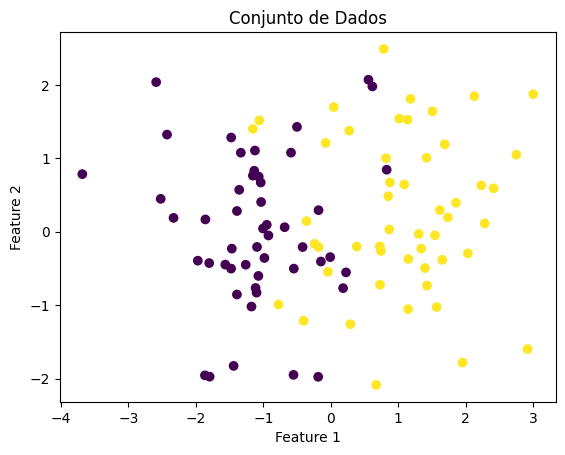

In [433]:
# Generate the dataset
np.random.seed(46)
X, y = make_classification(n_features=2, n_redundant=0, n_informative=1, n_clusters_per_class=1)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Conjunto de Dados')
plt.show()


In [434]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

perceptron = Perceptron()

In [435]:
perceptron.fit(X_train, y_train)
y_pred = perceptron.predict(X_test)
print(y_pred)

[1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 0 1 0 0]


In [436]:
# Pesos e viés
pesos = perceptron.coef_
vies = perceptron.intercept_
print(f'Pesos: {pesos}')
print(f'Viés: {vies}')

Pesos: [[ 2.39257278 -0.20771404]]
Viés: [0.]


In [437]:
# Avaliar o modelo
accuracy = perceptron.score(X, y)
print(f'Acurácia do Perceptron: {accuracy * 100:.2f}%')

Acurácia do Perceptron: 85.00%


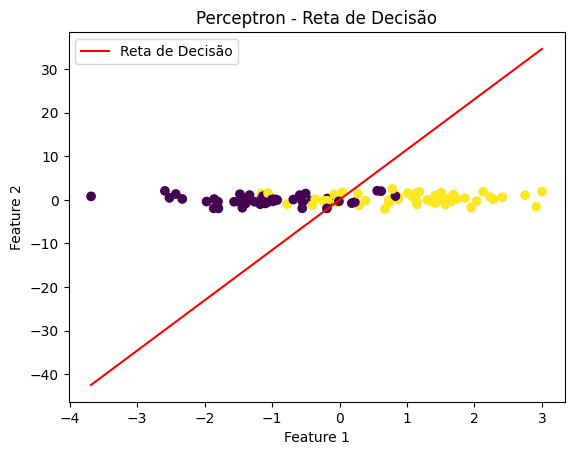

In [438]:
# Plotar os dados e a reta de decisão
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')

# Plotar a reta de decisão
x_values = [min(X[:, 0]), max(X[:, 0])]
y_values = -(pesos[0][0] * np.array(x_values) + vies) / pesos[0][1]
plt.plot(x_values, y_values, label='Reta de Decisão', color='red')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron - Reta de Decisão')
plt.legend()
plt.show()

In [439]:
# Criar e treinar o modelo MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(5, 3, 1), max_iter=1000)
mlp.fit(X, y)

MLPClassifier(hidden_layer_sizes=(5, 3, 1), max_iter=1000)

In [440]:
pesos = perceptron.coef_
vies = perceptron.intercept_
print(f'Pesos: {pesos}')
print(f'Viés: {vies}')

Pesos: [[ 2.39257278 -0.20771404]]
Viés: [0.]


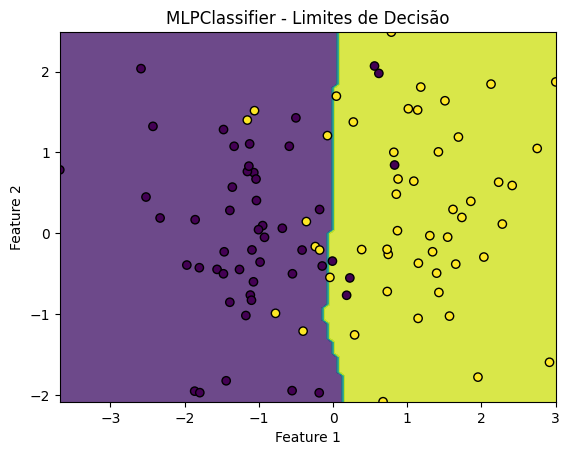

In [441]:
# Criar um grid de pontos para prever
xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
                     np.linspace(X[:, 1].min(), X[:, 1].max(), 100))

# Prever as classes para cada ponto do grid
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotar os limites de decisão
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap='viridis')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('MLPClassifier - Limites de Decisão')
plt.show()


## Base Íris

In [442]:
# Carregando o conjunto de dados Iris
iris = load_iris()
X = iris.data[:, :2]
y = iris.target

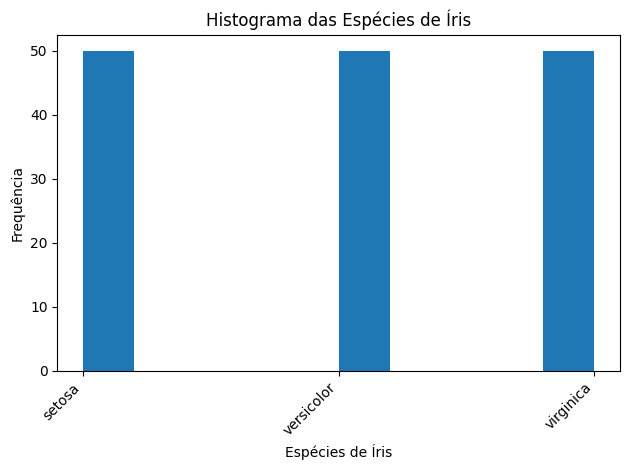

In [443]:
plt.hist(y)

plt.xticks(range(len(set(y))), iris.target_names, rotation=45, ha='right')

# Adicionar rótulos e título
plt.xlabel('Espécies de Íris')
plt.ylabel('Frequência')
plt.title('Histograma das Espécies de Íris')

# Mostrar o histograma
plt.tight_layout()
plt.show()

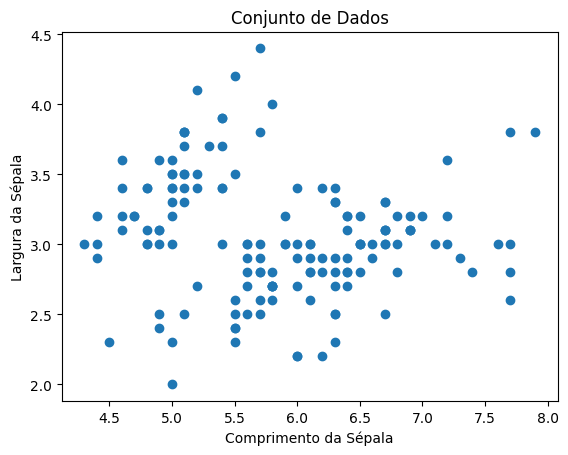

In [444]:
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('Comprimento da Sépala')
plt.ylabel('Largura da Sépala')
plt.title('Conjunto de Dados')
plt.show()

In [445]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

c:\Users\erikp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


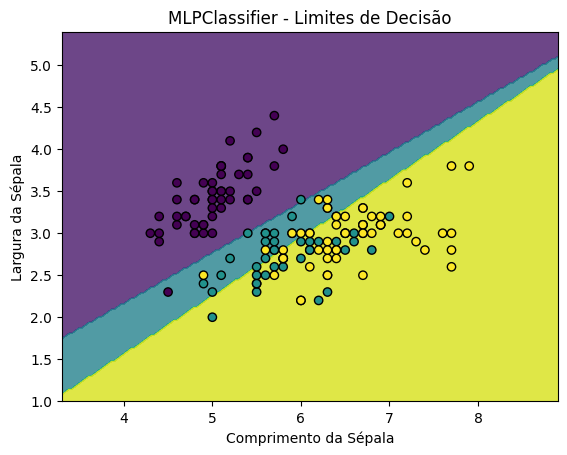

In [446]:
# Criar e treinar o modelo MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
mlp.fit(X, y)

# Criar um grid de pontos para prever
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() -1, X[:, 0].max() + 1, 200),
                     np.linspace(X[:, 1].min() -1, X[:, 1].max() + 1, 200))

# Prever as classes para cada ponto do grid
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotar os limites de decisão
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap='viridis')

plt.xlabel('Comprimento da Sépala')
plt.ylabel('Largura da Sépala')
plt.title('MLPClassifier - Limites de Decisão')
plt.show()

### Pesos e viés

In [447]:
pesos = perceptron.coef_
vies = perceptron.intercept_
print(f'Pesos: {pesos}')
print(f'Viés: {vies}')

Pesos: [[ 2.39257278 -0.20771404]]
Viés: [0.]


## Normalizado

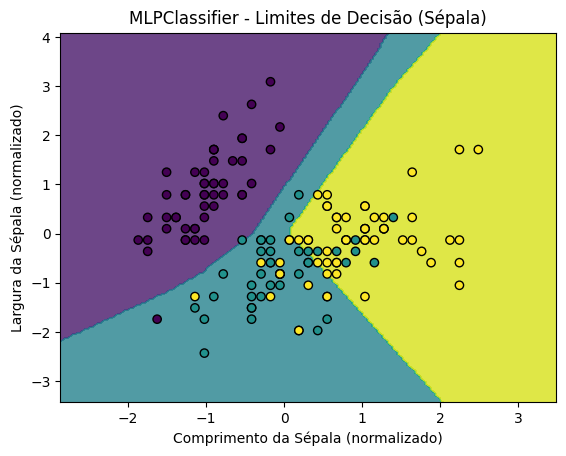

In [448]:
# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Criar e treinar o modelo MLPClassifier com arquitetura simplificada
mlp = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
mlp.fit(X_scaled, y)

# Criar um grid de pontos para prever
xx, yy = np.meshgrid(np.linspace(X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1, 200),
                     np.linspace(X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1, 200))

# Prever as classes para cada ponto do grid
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotar os limites de decisão
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k', marker='o', cmap='viridis')

plt.xlabel('Comprimento da Sépala (normalizado)')
plt.ylabel('Largura da Sépala (normalizado)')
plt.title('MLPClassifier - Limites de Decisão (Sépala)')
plt.show()


### Pesos e viés

In [449]:
pesos = perceptron.coef_
vies = perceptron.intercept_
print(f'Pesos: {pesos}')
print(f'Viés: {vies}')

Pesos: [[ 2.39257278 -0.20771404]]
Viés: [0.]


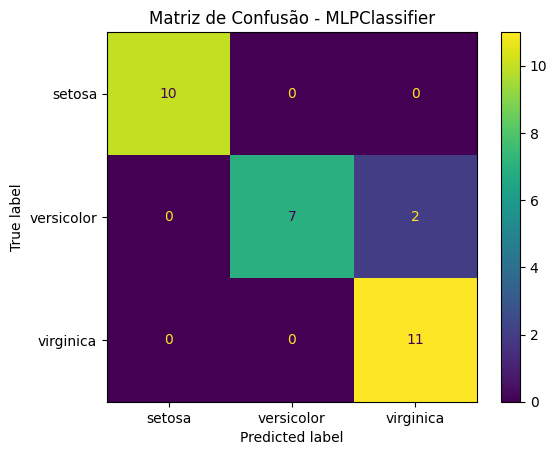

In [450]:
y_pred = mlp.predict(X_test_scaled)

# Calcular a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Exibir a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='viridis')
plt.title('Matriz de Confusão - MLPClassifier')
plt.show()

In [451]:
# Calcular e exibir métricas de avaliação
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia do MLPClassifier:", accuracy)

recall = recall_score(y_test, y_pred, average=None)  # Recall para cada classe
print("Recall para cada classe:", recall)

class_names = iris.target_names
report = classification_report(y_test, y_pred, target_names=class_names)
print("Relatório de Classificação:\n", report)

Acurácia do MLPClassifier: 0.9333333333333333
Recall para cada classe: [1.         0.77777778 1.        ]
Relatório de Classificação:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.78      0.88         9
   virginica       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

